In [1]:
# ==========================================
# Prodigy InfoTech Internship - Task 04
# Hand Gesture Recognition using CNN
# ==========================================



In [4]:
!pip install tensorflow matplotlib numpy

In [23]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [6]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [24]:

dataset_path = r"C:\Users\Manjunadh\leapGestRecog"

IMG_SIZE = 64

images = []
labels = []

In [26]:
for subject in os.listdir(dataset_path):

    subject_path = os.path.join(dataset_path, subject)

    if os.path.isdir(subject_path):

        for gesture in os.listdir(subject_path):

            gesture_path = os.path.join(subject_path, gesture)

            for img in os.listdir(gesture_path)[:100]:

                try:
                    img_path = os.path.join(gesture_path, img)

                    image = cv2.imread(img_path)

                    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

                    images.append(image)
                    labels.append(gesture)

                except:
                    pass

print("Total Images Loaded:", len(images))
print("Total Labels:", len(labels))

Total Images Loaded: 15200
Total Labels: 15200


In [27]:
X = np.array(images, dtype="float32") / 255.0

encoder = LabelEncoder()

y = encoder.fit_transform(labels)

y = to_categorical(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (15200, 64, 64, 3)
y Shape: (15200, 10)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 12160
Testing Samples: 3040


In [29]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(64,64,3)
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(y.shape[1], activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\Manjunadh\anaconda new\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,626,442 (6.20 MB)

 Trainable params: 1,626,442 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
380/380 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.8620 - loss: 0.4160 - val_accuracy: 0.9997 - val_loss: 0.0048
Epoch 2/5
380/380 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9851 - loss: 0.0477 - val_accuracy: 0.9997 - val_loss: 0.0027
Epoch 3/5
380/380 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.9887 - loss: 0.0347 - val_accuracy: 1.0000 - val_loss: 3.5752e-04
Epoch 4/5
380/380 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9916 - loss: 0.0238 - val_accuracy: 1.0000 - val_loss: 5.8797e-04
Epoch 5/5
380/380 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.9941 - loss: 0.0185 - val_accuracy: 0.9997 - val_loss: 5.0081e-04


In [31]:
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)

95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9997 - loss: 5.0081e-04

Test Accuracy: 0.9996710419654846


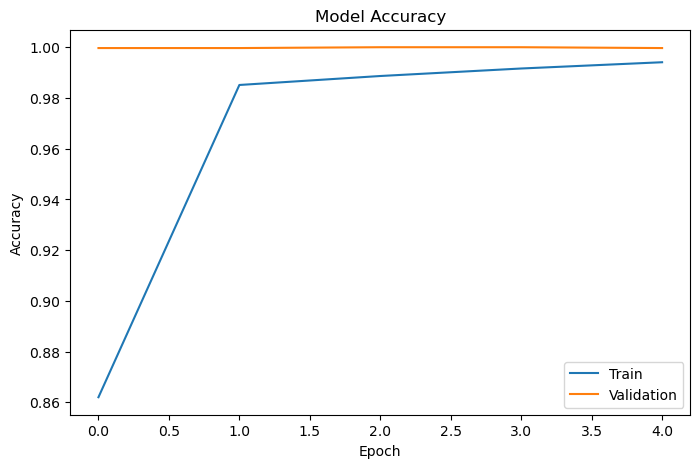

In [32]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

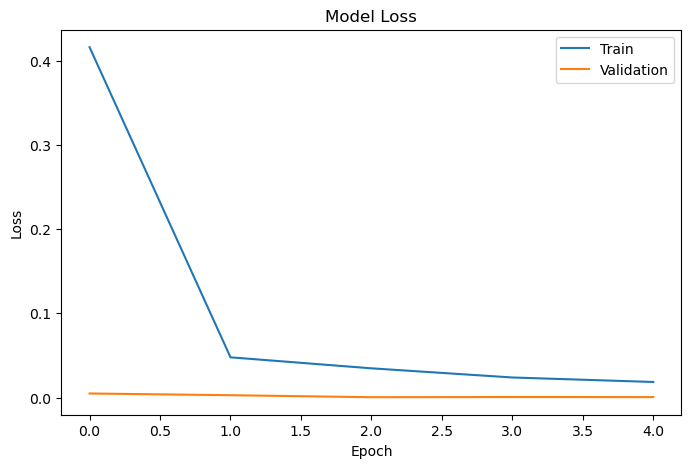

In [33]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step


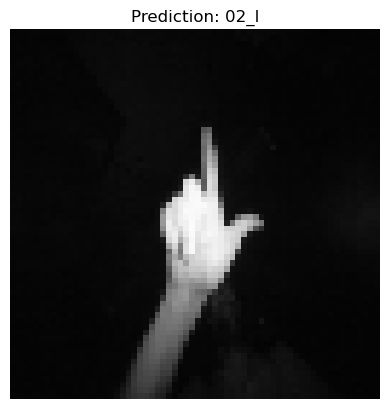

In [34]:
sample = X_test[0]

prediction = model.predict(
    np.expand_dims(sample, axis=0)
)

predicted_class = np.argmax(prediction)

gesture_name = encoder.inverse_transform(
    [predicted_class]
)

plt.imshow(sample)
plt.axis("off")

plt.title(
    f"Prediction: {gesture_name[0]}"
)

plt.show()